# CYNAR paper 1 -- example 2: bullfrog hair bundle (nonlinear, confined)

A nonlinear, physically-motivated active system (bullfrog hair-bundle model, 2D: gate coordinate $x$
and stereocilia coordinate $y$), confined but with no closed-form theory -- "ground truth" here comes
from `observables_from_trajectory`, which computes $\sigma,\mathcal{T},\mathcal{G}$ directly from the
known forces along the simulated trajectory (essentially exact, since it needs no fit or grid). This
complements `linear_vortex` as a second, nonlinear confined-system test of **merit B** (cell-size stability):
does CYNAR's $\sigma=4\mathcal{T}^\star+\mathcal{G}$ stay flatter across cell size than the $v^2$-method?

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, ".")
import numpy as np
import matplotlib.pyplot as plt

import cynar
from cynar.simul.hair import simulate_hair_bundle, observables_from_trajectory
from cynar.plot import plot_trajectory

import common as C

np.set_printoptions(precision=4, suppress=True)

## Model & simulation

In [2]:
kBT = 4.11
kBT_eff = 1.5 * kBT
mu1, mu2 = 357.1, 100.0
dt = 1e-4

# S_FEED, F_MAX, K_GS, K_SP, D_GATE, DELTAG, N_EL, MU1, MU2, KBT, KBT_EFF
pars = np.array([
    1.0, 75.0, 0.75, 0.60, 61.0, 10.0 * kBT, 50.0, mu1, mu2, kBT, kBT_eff,
], dtype=np.float64)

D = np.array([[mu1 * kBT, 0.0], [0.0, mu2 * kBT_eff]])

T = 1_000_000
t, X = simulate_hair_bundle(T=T, dt=dt, x0=0.0, y0=0.0, pars=pars, scheme="Heun", seed=0)

sigma_true, Tr_true, G_true = observables_from_trajectory(X, dt=dt, pars=pars)
true_values = dict(Tr_true=Tr_true, G_true=G_true, sigma_true=sigma_true)
print(f"Tr_true={Tr_true:.4f}  G_true={G_true:.4f}  sigma_true={sigma_true:.4f}"
      f"  (check 4*Tr+G={4*Tr_true+G_true:.4f})")

Tr_true=1727.2578  G_true=143.7728  sigma_true=7028.0951  (check 4*Tr+G=7052.8042)


### Example trajectory

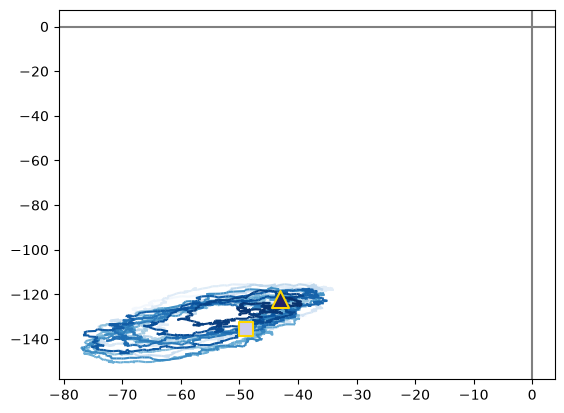

In [3]:
plot_trajectory(X, i=0, j=1, tmin=0, tmax=5000)

## Merit B: cell-size stability

Same procedure as for `linear_vortex`: an $H$-sweep picks a stable traffic estimate $\mathcal{T}^\star$,
then a cell-size sweep on the same grid compares CYNAR's $4\mathcal{T}^\star+\mathcal{G}(\Delta x)$ to the
$v^2$-method's $\sigma_{v^2}(\Delta x)$.

Note: the hair bundle is a spontaneously-oscillating system -- its correlation function decays smoothly
only up to $\tau\sim0.005$ (comparable to the fast relaxation time $1/[\mu_1(k_{gs}+k_{sp})]\approx0.002$)
before going *negative* (an oscillatory overshoot). The single exp-poly term used here cannot represent
that sign change, so unlike `linear_vortex`, this system needs a much tighter fit window
($i_1=2$, $H\lesssim0.15$) to stay inside the smooth part of the decay -- checked empirically: the wider
$H$ used for `linear_vortex` pulls in the oscillation and the fit becomes unstable (D_hat can even go
negative). The right window is system-dependent, not a fixed universal choice.

In [4]:
H_list = np.linspace(0.01, 0.12, 12)

# Ne=1 (the package default elsewhere) vs Ne=2: checked (see notebooks/02-PROVA.ipynb),
# T(H) under Ne=1 keeps climbing rather than plateauing over this H range -- a
# ground-truth-free warning sign that the single exp-poly term cannot represent
# this system's short-time correlation shape. Ne=2 gives a visibly flatter,
# better-converged T(H) and a Tr* much closer to the true value (see panel (a)
# below), so it is used as the default fit for everything downstream.
traffic_result_ne1 = C.sweep_traffic_vs_H(X, dt, H_list, N_slice=5, i1_window=2, Ne=1)
tr_star_ne1 = C.pick_stable_Tr(traffic_result_ne1)
print(f"Ne=1: H* = {tr_star_ne1['H_star']:.2f}  Tr* = {tr_star_ne1['Tr_star_mean']:.4f}"
      f" +/- {tr_star_ne1['Tr_star_std']:.4f}  (true {Tr_true:.4f})")

traffic_result_ne2 = C.sweep_traffic_vs_H(X, dt, H_list, N_slice=5, i1_window=2, Ne=2)
tr_star_ne2 = C.pick_stable_Tr(traffic_result_ne2)
print(f"Ne=2: H* = {tr_star_ne2['H_star']:.2f}  Tr* = {tr_star_ne2['Tr_star_mean']:.4f}"
      f" +/- {tr_star_ne2['Tr_star_std']:.4f}  (true {Tr_true:.4f})")

traffic_result, tr_star = traffic_result_ne2, tr_star_ne2

Ne=1: H* = 0.01  Tr* = 1724.1834 +/- 37.8199  (true 1727.2578)
Ne=2: H* = 0.02  Tr* = 1771.0315 +/- 30.1945  (true 1727.2578)


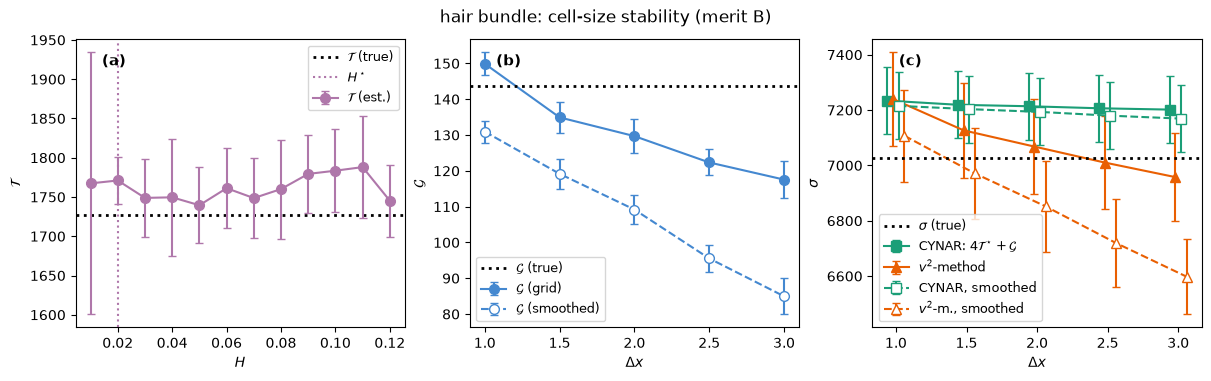

In [5]:
# Cell sizes common to panels (b)-(f): dx = side0 * R_list = [1, 1.5, 2, 2.5, 3].
# dx_fixed=1.5 is the single cell size panels (d), (e), (f) use below -- fixed
# rather than auto-picked (per Fmax or otherwise), so every panel in the
# composed figure refers to the same cell size.
side0 = (.5, .5)
R_list = np.array([2.0, 3.0, 4.0, 5.0, 6.0])
dx_fixed = 1.5

cellsize_result = C.sweep_cellsize(X, dt, traffic_result["D_from_traffic"], side0, R_list, traffic_result["slices"])

fig, axs = C.plot_cellsize_stability(
    traffic_result, tr_star, cellsize_result, true_values,
    title="hair bundle: cell-size stability (merit B)",
    save_path=str(C.FIGURES_DIR / "hair_cellsize.pdf"),
)
plt.show()

C.save_result("hair_cellsize", dict(
    traffic_result=traffic_result, tr_star=tr_star, cellsize_result=cellsize_result,
    true_values=true_values, pars=pars, side0=side0,
))

## Reconstructed fields

What CYNAR actually estimates from the trajectory: the density $\hat\rho(\boldsymbol{x})$, the local mean velocity
$\hat\nu(\boldsymbol{x})$ (used by the $v^2$-method), and the score $\hat s(\boldsymbol{x})=\nabla\ln\hat\rho(\boldsymbol{x})$ (used by
the inflow rate), each shown as a quiver over the reconstructed density.

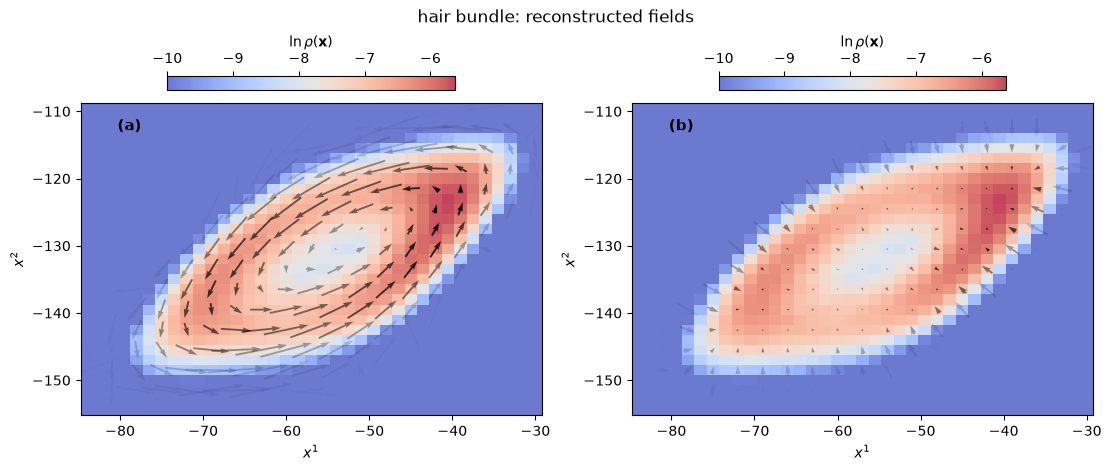

In [6]:
from cynar.plot import plot_field_rho
from cynar import cfg, inflow

# Same fixed cell size as panels (b)-(d) (dx_fixed=1.5), so the fields shown
# here are literally the grid CYNAR builds for that comparison, not a
# separately-tuned illustrative resolution.
side_recon = np.array([dx_fixed, dx_fixed])
D_recon = traffic_result["D_from_traffic"][0]
icfg_recon = cfg.InflowCfg(n_min=2, thr_g=200.0)
out_recon = inflow.grid_inflow(X, dt, side_recon, D_recon, cfg=icfg_recon)

edges = out_recon["grid"]["edges"]
rho = out_recon["grid"]["rho"]
nu = out_recon["grid"]["nu"]
s = out_recon["grid"]["g"]

fig, axs = plt.subplots(1, 2, figsize=(11, 4.6), constrained_layout=True)
plot_field_rho(edges, rho, nu, ax=axs[0], log=True, stride=2, quiver_scale=800, quiver_width=0.004, obs=r"$\nu$", show_title=False, panel_label="(a)")
plot_field_rho(edges, rho, s, ax=axs[1], log=True, stride=2, quiver_scale=0.5, quiver_width=0.004, obs=r"$s$", show_title=False, panel_label="(b)")
fig.suptitle("hair bundle: reconstructed fields")
fig.savefig(str(C.FIGURES_DIR / "hair_fields.pdf"), dpi=200, bbox_inches="tight")
plt.show()

## Dissipation vs motor-force amplitude

Following Di Terlizzi *et al.* (Fig. 2(d) of the companion PRL), we sweep the motor-force amplitude
$F_{\rm max}$ at fixed calcium-feedback strength $S=1$ and compare CYNAR and the $v^2$-method against
ground truth. Unlike the linear model's $\beta$-sweep, this is not an equilibrium-crossing test (the
hair-bundle model has no accessible equilibrium point along this one-parameter family), but it is the
same validation the original method was benchmarked against, and it captures a real dynamical feature:
the bundle's dissipation rises sharply with $F_{\rm max}$ as it crosses into a spontaneously oscillating
regime, peaks, then declines again as the motor force grows large enough to lock the bundle away from
the oscillatory limit cycle. (Below $F_{\rm max}\simeq47$ the bundle is essentially quiescent, with
$\sigma_{\rm true}$ dropping to order 1: at that point the traffic fit window tuned for the oscillatory
regime above is no longer appropriate, and the estimate becomes unreliable -- consistent with the
system-dependence of the fit window documented in Appendix A. We therefore restrict this sweep to the
well-conditioned oscillatory regime, as Di Terlizzi *et al.* effectively did too.)

This sweep now shares everything with panels (a)-(c) above: the same trajectory length ($T=1{,}000{,}000$
steps for every $F_{\rm max}$, not a shorter one), the same absolute cell-size grid
$\Delta x\in\{1,1.5,2,2.5,3\}$ (no per-$F_{\rm max}$ rescaling by the trajectory's spread), and the same
fixed $\Delta x=1.5$ read off for $\sigma_{\rm CYNAR}$/$\sigma_{v^2}$ at every point, rather than an
automatically picked $\Delta x^\star$. The $F_{\rm max}=75$ point below is not resimulated: it reuses the
exact traffic and cell-size sweep computed for panels (b)/(c), so that point in panel (d) is literally the
same computation, not an independent draw of the same random pipeline. Fixing $\Delta x$ rather than
rescaling it per $F_{\rm max}$ does mean the grid is not equally well matched to every point -- the
trajectory's spread varies by close to 4x across this sweep (quiescent/over-driven regimes vs. the
oscillation peak) -- so panels away from $F_{\rm max}=75$ may be somewhat over- or under-resolved relative
to their own natural scale.

In [7]:
from cynar.simul.hair import F_MAX

Fmax_list = np.array([50.0, 60.0, 75.0, 90.0, 110.0, 140.0, 180.0, 230.0])
idx_fixed = int(np.argmin(np.abs(R_list * side0[0] - dx_fixed)))  # index of dx_fixed within the dx grid above

fmax_main = float(pars[F_MAX])  # this notebook's main example point (panels a-c, e-f)
traffic_by_fmax = {fmax_main: traffic_result}
tr_star_by_fmax = {fmax_main: tr_star}
cellsize_by_fmax = {fmax_main: cellsize_result}

sigma_true_list, Tr_true_list = [], []
sigma_cynar_mean, sigma_cynar_std = [], []
sigma_v2_mean, sigma_v2_std = [], []

for fmax in Fmax_list:
    if np.isclose(fmax, fmax_main):
        # Same point as panels (b)/(c): reuse that exact computation (same
        # trajectory X, same H-sweep and cell-size sweep) instead of
        # resimulating, so this really is one of the cases of this sweep,
        # not an independent draw of the same random pipeline.
        traffic_f, tr_star_f, cellsize_f = traffic_result, tr_star, cellsize_result
        sigma_t, Tr_t = sigma_true, Tr_true
    else:
        pars_f = pars.copy()
        pars_f[F_MAX] = fmax
        _, X_f = simulate_hair_bundle(T=T, dt=dt, x0=0.0, y0=0.0, pars=pars_f, scheme="Heun", seed=0)
        sigma_t, Tr_t, G_t = observables_from_trajectory(X_f, dt=dt, pars=pars_f)

        traffic_f = C.sweep_traffic_vs_H(X_f, dt, H_list, N_slice=5, i1_window=2, Ne=2)
        tr_star_f = C.pick_stable_Tr(traffic_f)
        cellsize_f = C.sweep_cellsize(X_f, dt, traffic_f["D_from_traffic"], side0, R_list, traffic_f["slices"])

        traffic_by_fmax[fmax] = traffic_f
        tr_star_by_fmax[fmax] = tr_star_f
        cellsize_by_fmax[fmax] = cellsize_f

    sigma_true_list.append(sigma_t)
    Tr_true_list.append(Tr_t)

    sg_mean, sg_std = C.combine_sigma_cynar(
        tr_star_f["Tr_star_mean"], tr_star_f["Tr_star_std"],
        cellsize_f["Gb_mean"][idx_fixed], cellsize_f["Gb_std"][idx_fixed],
    )
    sigma_cynar_mean.append(sg_mean); sigma_cynar_std.append(sg_std)
    sigma_v2_mean.append(cellsize_f["sigma_v2_mean"][idx_fixed])
    sigma_v2_std.append(cellsize_f["sigma_v2_std"][idx_fixed])

    print(f"Fmax={fmax:6.1f}  sigma_true={sigma_t:9.2f}"
          f"  sigma_CYNAR={sg_mean:9.2f}+/-{sg_std:.2f}"
          f"  sigma_v2={cellsize_f['sigma_v2_mean'][idx_fixed]:9.2f}+/-{cellsize_f['sigma_v2_std'][idx_fixed]:.2f}")

sigma_true_list = np.array(sigma_true_list)
sigma_cynar_mean = np.array(sigma_cynar_mean); sigma_cynar_std = np.array(sigma_cynar_std)
sigma_v2_mean = np.array(sigma_v2_mean); sigma_v2_std = np.array(sigma_v2_std)

C.save_result("hair_fmax_sweep", dict(
    Fmax_list=Fmax_list, sigma_true_list=sigma_true_list, Tr_true_list=Tr_true_list,
    sigma_cynar_mean=sigma_cynar_mean, sigma_cynar_std=sigma_cynar_std,
    sigma_v2_mean=sigma_v2_mean, sigma_v2_std=sigma_v2_std, dx_fixed=dx_fixed,
))

Fmax=  50.0  sigma_true=  1404.34  sigma_CYNAR=  1456.63+/-47.67  sigma_v2=  1500.16+/-53.63
Fmax=  60.0  sigma_true=  5082.97  sigma_CYNAR=  5232.56+/-113.81  sigma_v2=  5268.29+/-103.16
Fmax=  75.0  sigma_true=  7028.10  sigma_CYNAR=  7219.05+/-120.86  sigma_v2=  7126.53+/-172.57
Fmax=  90.0  sigma_true=  5516.06  sigma_CYNAR=  5746.40+/-44.46  sigma_v2=  5583.72+/-103.53
Fmax= 110.0  sigma_true=  3067.21  sigma_CYNAR=  2682.62+/-66.42  sigma_v2=  2970.04+/-95.50
Fmax= 140.0  sigma_true=  1661.18  sigma_CYNAR=  1385.57+/-97.96  sigma_v2=  1554.27+/-89.48
Fmax= 180.0  sigma_true=  1109.51  sigma_CYNAR=   914.90+/-24.54  sigma_v2=  1009.25+/-23.96
Fmax= 230.0  sigma_true=   862.41  sigma_CYNAR=   694.97+/-25.79  sigma_v2=   774.35+/-21.96


In [8]:
print(idx_fixed)
print(cellsize_f["Gb_mean"][idx_fixed], cellsize_f["Gb_std"][idx_fixed],)

1
562.7779185515978 12.081256984323353


### All five cell sizes, not just the fixed one

The loop above already evaluates the cell-size sweep at every $F_{\rm max}$ (that is what
`C.sweep_cellsize` does internally), even though panel (d) only reads off the single fixed
$\Delta x=$`dx_fixed` column. This reuses that otherwise-discarded data, stored per $F_{\rm max}$ in
`tr_star_by_fmax`/`cellsize_by_fmax`, to show $\sigma_{\rm CYNAR}(F_{\rm max})$ and
$\sigma_{v^2}(F_{\rm max})$ at every cell size in the grid, not just the one used above -- no
resimulation needed.

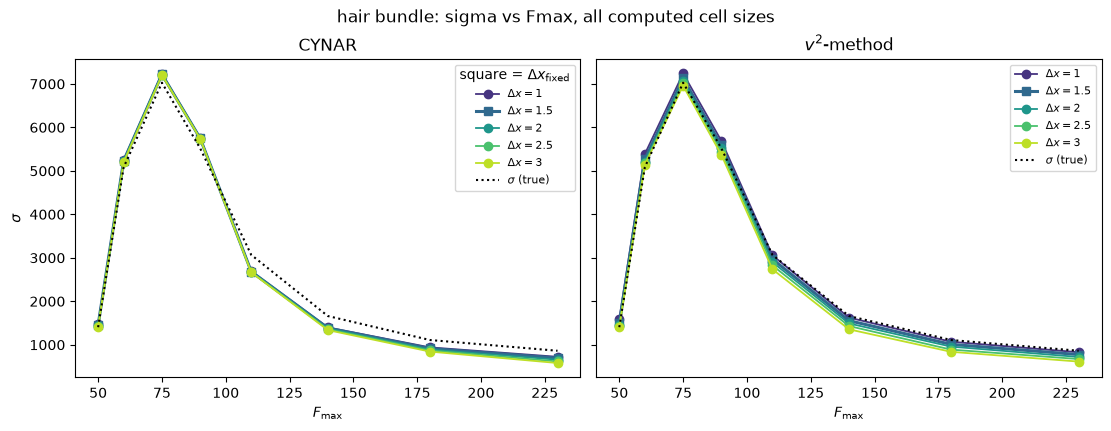

In [9]:
dx_grid = R_list * side0[0]

sigma_cynar_dx = np.zeros((len(dx_grid), len(Fmax_list)))
sigma_v2_dx = np.zeros((len(dx_grid), len(Fmax_list)))

for j, fmax in enumerate(Fmax_list):
    tr_star_f = tr_star_by_fmax[fmax]
    cellsize_f = cellsize_by_fmax[fmax]
    sg_mean, _ = C.combine_sigma_cynar(
        tr_star_f["Tr_star_mean"], tr_star_f["Tr_star_std"],
        cellsize_f["Gb_mean"], cellsize_f["Gb_std"],
    )
    sigma_cynar_dx[:, j] = sg_mean
    sigma_v2_dx[:, j] = cellsize_f["sigma_v2_mean"]

fig, axs = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True, sharey=True)
cmap = plt.cm.viridis
colors = [cmap(x) for x in np.linspace(0.15, 0.9, len(dx_grid))]

for i, dx in enumerate(dx_grid):
    is_fixed = np.isclose(dx, dx_fixed)
    marker = "s" if is_fixed else "o"
    lw = 2.2 if is_fixed else 1.3
    axs[0].plot(Fmax_list, sigma_cynar_dx[i], marker=marker, lw=lw, color=colors[i], label=fr"$\Delta x={dx:g}$")
    axs[1].plot(Fmax_list, sigma_v2_dx[i], marker=marker, lw=lw, color=colors[i], label=fr"$\Delta x={dx:g}$")

axs[0].plot(Fmax_list, sigma_true_list, "k:", label=r"$\sigma$ (true)")
axs[1].plot(Fmax_list, sigma_true_list, "k:", label=r"$\sigma$ (true)")
axs[0].set_title("CYNAR")
axs[1].set_title(r"$v^2$-method")
axs[0].set_xlabel(r"$F_{\rm max}$"); axs[1].set_xlabel(r"$F_{\rm max}$")
axs[0].set_ylabel(r"$\sigma$")
axs[0].legend(fontsize=8, title=r"square = $\Delta x_{\rm fixed}$")
axs[1].legend(fontsize=8)
fig.suptitle("hair bundle: sigma vs Fmax, all computed cell sizes")
fig.savefig(str(C.FIGURES_DIR / "hair_fmax_all_dx.pdf"), dpi=200, bbox_inches="tight")
plt.show()

## Composed summary figure (3x2)

Same idea as the linear-drift summary figures: reassemble the reconstructed-field panels, the
cell-size-stability panels, and the $F_{\rm max}$-sweep panel into one 3x2 figure with PRE-style
(a)-(f) tags, ordered to match the paper's panel-order narrative: (a)-(b) reconstructed fields first,
then (c) traffic, (d) inflow rate, (e) $\sigma$ vs. cell size, (f) $\sigma$ vs. $F_{\rm max}$.

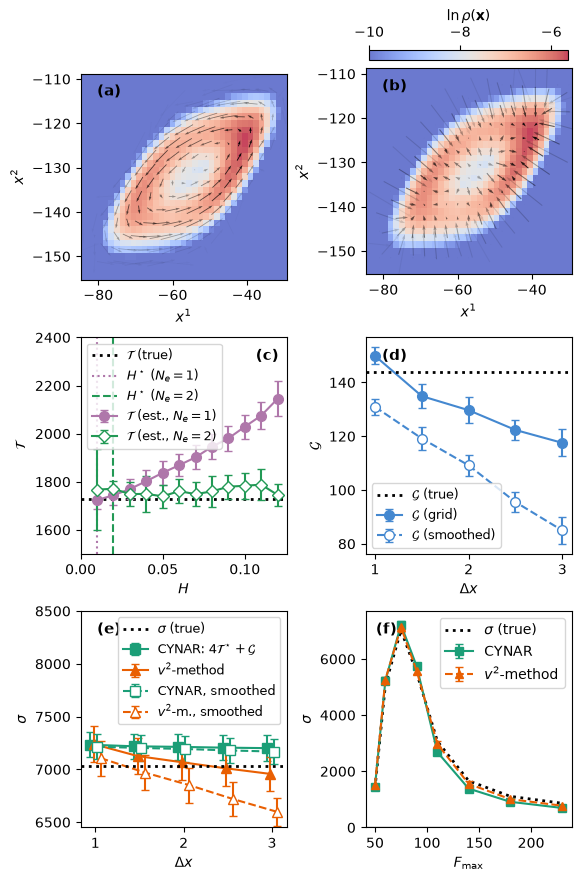

In [15]:
fig, axs = plt.subplots(3, 2, figsize=(5.7, 8.7), constrained_layout=True)

# (a)-(b): reconstructed fields first, same panel-order convention as the linear-drift
# figures; (a) drops its colorbar and both get a square box aspect so removing it
# doesn't unbalance (a) vs (b), letting (b)'s colorbar stick out to the right instead.
plot_field_rho(edges, rho, nu, ax=axs[0, 0], log=True, stride=2, quiver_scale=800, quiver_width=0.004,
               obs=r"$\nu$", show_title=False, panel_label="(a)", colorbar=False)
plot_field_rho(edges, rho, s, ax=axs[0, 1], log=True, stride=2, quiver_scale=0.125, quiver_width=0.005,
               obs=r"$s$", show_title=False, panel_label="(b)")
axs[0, 0].set_box_aspect(1)
axs[0, 1].set_box_aspect(1)

C.plot_traffic_vs_H_panel(axs[1, 0], traffic_result_ne1, tr_star_ne1, true_values, panel_label="(c)",
                         panel_label_kw=dict(pad_x=0.85, pad_y=0.05),
                         traffic_result2=traffic_result_ne2, tr_star2=tr_star_ne2)
C.plot_inflow_vs_cellsize_panel(axs[1, 1], cellsize_result, true_values, panel_label="(d)")

C.plot_sigma_vs_cellsize_panel(axs[2, 0], tr_star, cellsize_result, true_values, panel_label="(e)")
C.plot_equilibrium_bias_panel(
    axs[2, 1], Fmax_list, sigma_cynar_mean, sigma_cynar_std, sigma_v2_mean, sigma_v2_std,
    param_label=r"$F_{\rm max}$", equilibrium_value=None, sigma_true=sigma_true_list,
    panel_label="(f)", panel_label_kw=dict(pad_x=0.05, pad_y=0.05),
)

axs[1, 0].legend(loc="upper left", fontsize=9)
axs[1, 0].set_xlim(0,)
axs[2, 1].set_ylim(0,)
axs[2, 0].set_ylim(6450, 8500)
axs[1, 0].set_ylim(1500, 2400)

fig.savefig(str(C.FIGURES_DIR / "hair_summary.pdf"), dpi=300, bbox_inches="tight")
plt.show()

In [11]:
C.FIGURES_DIR

PosixPath('figures')